# Exp 28.07.2026 — Handling Missing Data & Imputation Techniques
1. Handling Missing Values
2. Imputation Techniques


## Setup & Sample Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer

np.random.seed(42)
n = 200

df = pd.DataFrame({
    'student_id': range(1, n + 1),
    'attendance_pct': np.random.normal(78, 10, n).round(1),
    'internal_marks': np.random.normal(35, 7, n).round(1),
    'study_hours_per_week': np.random.normal(12, 4, n).round(1),
    'cgpa': np.random.normal(7.5, 0.9, n).round(2),
    'department': np.random.choice(['CSE', 'ECE', 'MECH', 'CIVIL'], n)
})

# Inject missingness (different rates per column, to mimic real-world patterns)
for col, frac in [('attendance_pct', 0.10), ('internal_marks', 0.15),
                   ('study_hours_per_week', 0.08), ('cgpa', 0.05),
                   ('department', 0.06)]:
    idx = np.random.choice(df.index, size=int(frac * n), replace=False)
    df.loc[idx, col] = np.nan

df.head(10)

,student_id,attendance_pct,internal_marks,study_hours_per_week,cgpa,department
0,1,83.0,37.5,5.6,8.18,ECE
1,2,76.6,38.9,9.6,6.67,MECH
2,3,84.5,42.6,12.0,8.28,ECE
3,4,93.2,42.4,12.2,8.72,MECH
4,5,NaN,25.4,10.2,7.87,CSE
5,6,75.7,28.4,NaN,9.19,ECE
6,7,93.8,38.6,7.7,6.80,MECH
7,8,85.7,38.6,11.4,6.38,CIVIL
8,9,73.3,38.6,12.5,5.90,MECH
9,10,83.4,62.0,14.1,8.85,CIVIL


## 1. Handling Missing Data

### 1.1 Detecting missing values

In [2]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary.missing_count > 0].sort_values('missing_pct', ascending=False)
missing_summary

,missing_count,missing_pct
internal_marks,30,15.0
attendance_pct,20,10.0
study_hours_per_week,16,8.0
department,12,6.0
cgpa,10,5.0


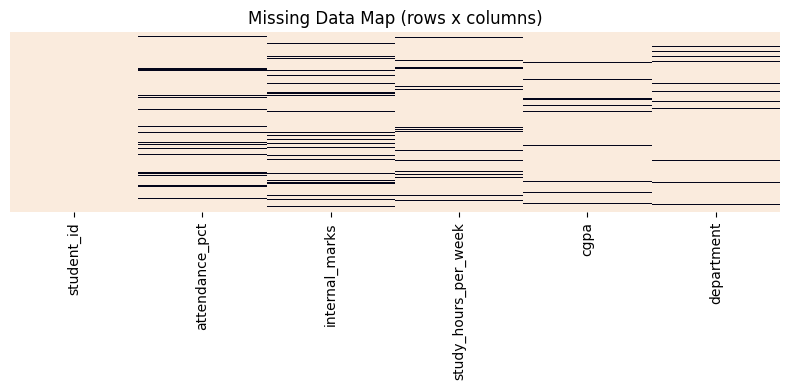

In [ ]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='rocket_r', yticklabels=False)
plt.title('Missing Data Map (rows x columns)')
plt.tight_layout()
plt.show()

### 1.3 Deletion strategies
**a) Listwise deletion (drop rows with any missing value)**

In [4]:
df_listwise = df.dropna()
print(f"Original rows: {len(df)}  ->  After listwise deletion: {len(df_listwise)}")
print(f"Rows lost: {len(df) - len(df_listwise)} ({(1 - len(df_listwise)/len(df))*100:.1f}%)")

Original rows: 200  ->  After listwise deletion: 123
Rows lost: 77 (38.5%)


**b) Column deletion (drop a column if it is missing beyond a threshold, e.g. 40%)**

In [5]:
threshold = 0.40
cols_to_drop = missing_summary[missing_summary.missing_pct > threshold * 100].index.tolist()
df_col_dropped = df.drop(columns=cols_to_drop)
print("Columns dropped:", cols_to_drop if cols_to_drop else "None (no column exceeds threshold)")

Columns dropped: None (no column exceeds threshold)


**c) Pairwise deletion** — instead of dropping rows outright, some computations (e.g. correlation) can use all *available* pairs per calculation:

In [6]:
corr_pairwise = df[['attendance_pct', 'internal_marks', 'study_hours_per_week', 'cgpa']].corr()
corr_pairwise

,attendance_pct,internal_marks,study_hours_per_week,cgpa
attendance_pct,1.000000,0.160655,-0.121013,0.071645
internal_marks,0.160655,1.000000,-0.031007,-0.129399
study_hours_per_week,-0.121013,-0.031007,1.000000,0.150346
cgpa,0.071645,-0.129399,0.150346,1.000000


> **Trade-off:** Deletion is simple and unbiased under MCAR, but here listwise deletion would discard a large chunk of usable rows since missingness is spread across different columns — this motivates imputation instead of deletion for this dataset.

## 2. Imputation Techniques
We keep a working copy `df_imp` and apply each technique to a *fresh copy* so effects can be compared side-by-side.

### 2.1 Mean / Median imputation (numeric)

In [7]:
df_mean = df.copy()
df_median = df.copy()

num_cols = ['attendance_pct', 'internal_marks', 'study_hours_per_week', 'cgpa']

mean_imputer = SimpleImputer(strategy='mean')
median_imputer = SimpleImputer(strategy='median')

df_mean[num_cols] = mean_imputer.fit_transform(df[num_cols])
df_median[num_cols] = median_imputer.fit_transform(df[num_cols])

df_mean[num_cols].isnull().sum()

attendance_pct          0
internal_marks          0
study_hours_per_week    0
cgpa                    0
dtype: int64

### 2.2 Mode imputation (categorical)

In [8]:
df_mode = df.copy()
mode_imputer = SimpleImputer(strategy='most_frequent')
df_mode[['department']] = mode_imputer.fit_transform(df[['department']])
df_mode['department'].isnull().sum()

np.int64(0)

### 2.3 Forward fill / Backward fill
Useful when data has a natural order (e.g. time series, roll-number order).

In [9]:
df_ffill = df.copy()
df_ffill[num_cols] = df_ffill[num_cols].ffill()

df_bfill = df.copy()
df_bfill[num_cols] = df_bfill[num_cols].bfill()

df_ffill[num_cols].isnull().sum()

attendance_pct          0
internal_marks          0
study_hours_per_week    0
cgpa                    0
dtype: int64

### 2.4 Linear interpolation

In [10]:
df_interp = df.copy()
df_interp[num_cols] = df_interp[num_cols].interpolate(method='linear', limit_direction='both')
df_interp[num_cols].isnull().sum()

attendance_pct          0
internal_marks          0
study_hours_per_week    0
cgpa                    0
dtype: int64

### 2.5 KNN imputation
Estimates a missing value from the *k* most similar rows (by the other numeric columns) rather than a single global statistic — usually more accurate than mean/median.

In [11]:
df_knn = df.copy()
knn_imputer = KNNImputer(n_neighbors=5)
df_knn[num_cols] = knn_imputer.fit_transform(df[num_cols])
df_knn[num_cols].isnull().sum()

attendance_pct          0
internal_marks          0
study_hours_per_week    0
cgpa                    0
dtype: int64

### 2.6 Regression imputation
Predict the missing column from the other numeric columns using a simple linear model, fit only on rows where the target is observed.

In [12]:
from sklearn.linear_model import LinearRegression

def regression_impute(data, target_col, feature_cols):
    data = data.copy()
    known = data[data[target_col].notna()]
    unknown = data[data[target_col].isna()]

    if unknown.empty:
        return data

    # Use rows with complete features for training
    train = known.dropna(subset=feature_cols)
    model = LinearRegression()
    model.fit(train[feature_cols], train[target_col])

    predict_rows = unknown.dropna(subset=feature_cols)
    if not predict_rows.empty:
        preds = model.predict(predict_rows[feature_cols])
        data.loc[predict_rows.index, target_col] = preds
    return data

df_regression = df.copy()
feature_cols = ['attendance_pct', 'study_hours_per_week']
df_regression = regression_impute(df_regression, 'internal_marks', feature_cols)
df_regression['internal_marks'].isnull().sum()

np.int64(5)

## 3. Comparing the Techniques
Imputation can distort the original distribution — mean/median imputation in particular shrinks variance by piling values at a single point. Visualizing the distribution before/after helps justify which method to use.

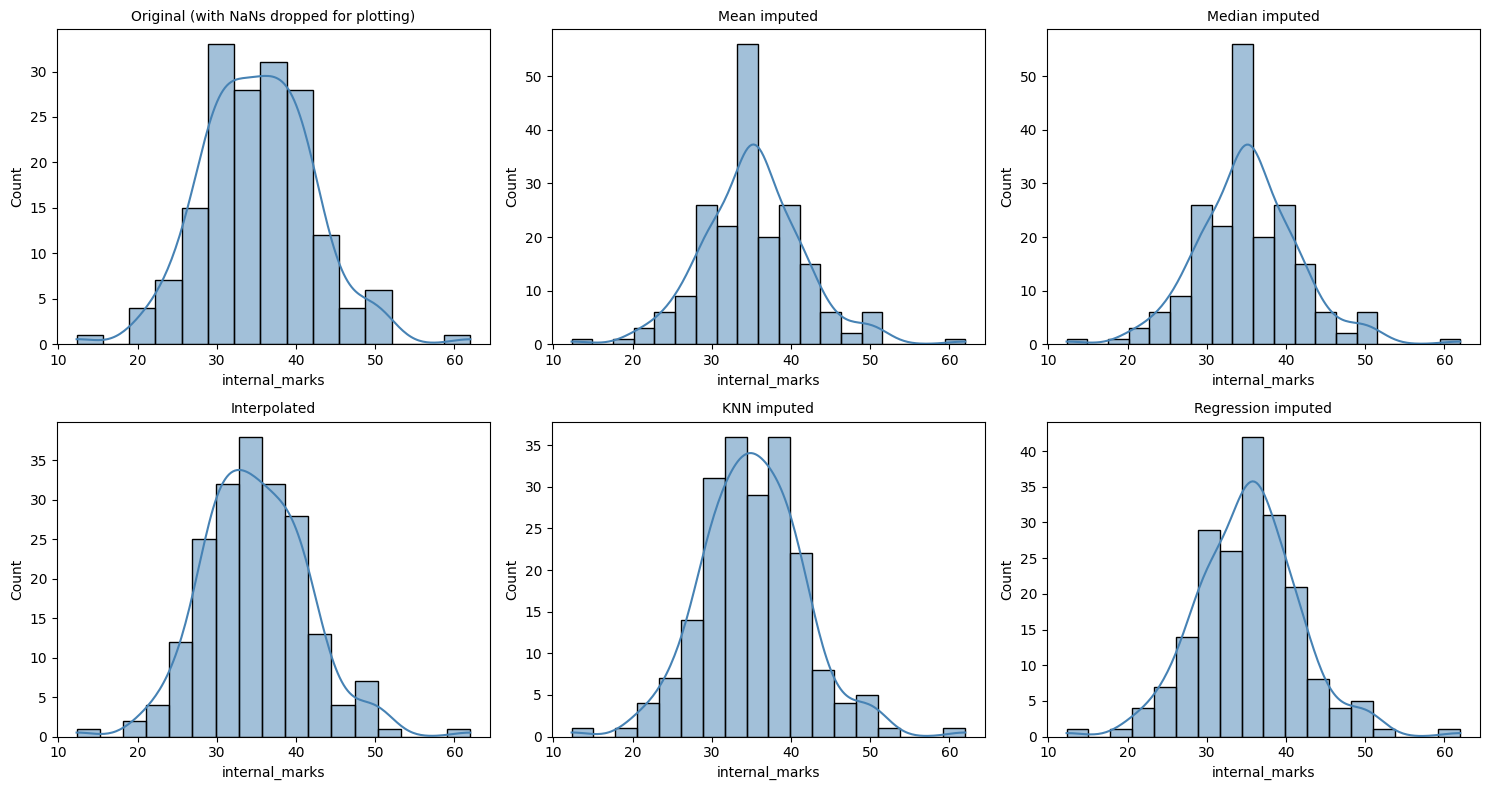

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
col = 'internal_marks'

results = {
    'Original (with NaNs dropped for plotting)': df[col].dropna(),
    'Mean imputed': df_mean[col],
    'Median imputed': df_median[col],
    'Interpolated': df_interp[col],
    'KNN imputed': df_knn[col],
    'Regression imputed': df_regression[col],
}

for ax, (title, series) in zip(axes.flat, results.items()):
    sns.histplot(series, kde=True, ax=ax, color='steelblue')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

In [14]:
summary = pd.DataFrame({
    method: {'mean': s.mean().round(2), 'std': s.std().round(2), 'missing_left': int(s.isnull().sum())}
    for method, s in results.items()
}).T
summary

,mean,std,missing_left
Original (with NaNs dropped for plotting),35.20,6.99,0.0
Mean imputed,35.20,6.44,0.0
Median imputed,35.18,6.44,0.0
Interpolated,34.90,6.65,0.0
KNN imputed,35.20,6.52,0.0
Regression imputed,35.27,6.54,5.0


### 3.1 Observations
- **Mean/median imputation** keeps the central tendency close to the original but visibly compresses the spread (lower std) since every missing slot gets the same fixed value.
- **Interpolation** preserves more local variation but assumes a meaningful row order, which may not hold for this dataset (student IDs aren't sequential in a meaningful sense here).
- **KNN imputation** tracks the original distribution shape most closely, since each missing value is filled using similar students rather than one global number.
- **Regression imputation** captures the linear relationship with attendance/study hours, so it works well when those predictors are genuinely correlated with the target.

### 3.2 Choosing a technique
| Situation | Suggested approach |
|---|---|
| Missing < 5%, MCAR | Simple deletion is fine |
| Numeric, roughly symmetric distribution | Mean imputation |
| Numeric, skewed / outliers present | Median imputation |
| Categorical | Mode imputation |
| Ordered/time-series data | Forward/backward fill or interpolation |
| Strong correlation with other numeric columns | KNN or regression imputation |
| MNAR (missingness itself is informative) | Add a "was_missing" indicator column, then impute |


## 4. Conclusion
This experiment demonstrated the full missing-data workflow: **detect → understand the mechanism (MCAR/MAR/MNAR) → decide between deletion and imputation → apply and compare multiple imputation methods**. For this dataset, KNN and regression imputation preserved the original distribution best, while mean/median imputation — though simplest — noticeably reduced variance and would understate the true spread of student performance.